## ROBERTS MEJORADO

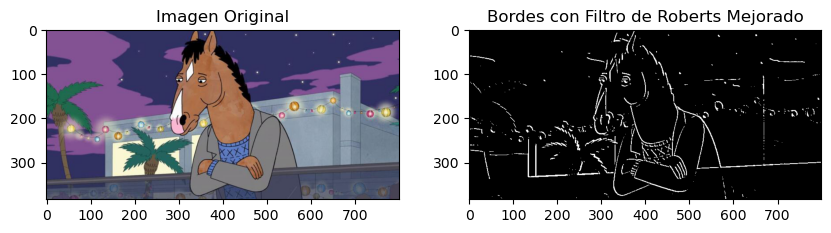

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts_mejorado(img):
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizar= cv2.GaussianBlur(img_gris,(3,3),0)
    robertx=np.array([[-2,0],[0,-2]],dtype=np.float32)
    roberty=np.array([[0,2],[-2,0]],dtype=np.float32)
    r_x=cv2.filter2D(suavizar,-1,robertx)
    r_y=cv2.filter2D(suavizar,-1,roberty)
    roberts=cv2.addWeighted(np.abs(r_x),0.7,np.abs(r_y),0.7,0)
    _,bordes=cv2.threshold(roberts,20,255,cv2.THRESH_BINARY) #el cv.THRESH_OTSU es opcinal
    return bordes


img=cv2.imread('imagen1.jpg')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.title('Bordes con Filtro de Roberts Mejorado')
plt.imshow(filtro_roberts_mejorado(img), cmap='gray')
plt.show()

## FILTRO PREWITT MEJORADO

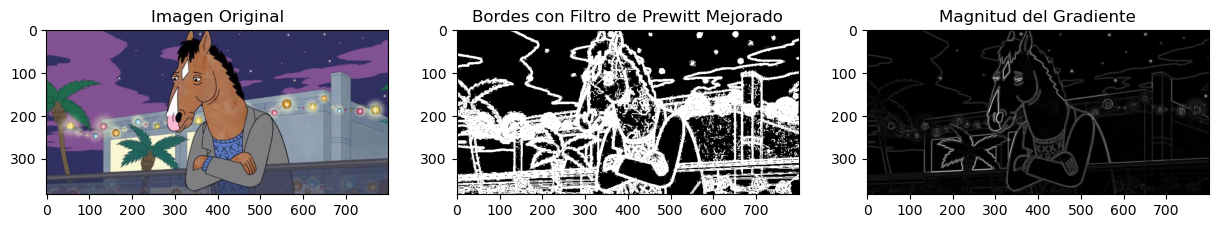

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_prewitt_mejorado(img):
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizar= cv2.GaussianBlur(img_gris,(3,3),0)

    kernelx=np.array([[-3,0,3],[-3,0,3],[-3,0,3]],dtype=np.float32)
    kernely=np.array([[3,3,3],[0,0,0],[-3,-3,-3]],dtype=np.float32)

    grad_x=cv2.filter2D(suavizar,cv2.CV_64F,kernelx)
    grad_y=cv2.filter2D(suavizar,cv2.CV_64F,kernely)

    magnitud=np.sqrt(grad_x**2 + grad_y**2)
    _,bordes=cv2.threshold(magnitud,20,255,cv2.THRESH_BINARY) 
    return bordes

img=cv2.imread('imagen1.jpg')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.title('Bordes con Filtro de Prewitt Mejorado')
bordes=filtro_prewitt_mejorado(img)
plt.imshow(bordes, cmap='gray')
plt.subplot(1,3,3)  
plt.title('Magnitud del Gradiente')
plt.imshow(magnitud, cmap='gray')
plt.show()

## FILTRO CANNY

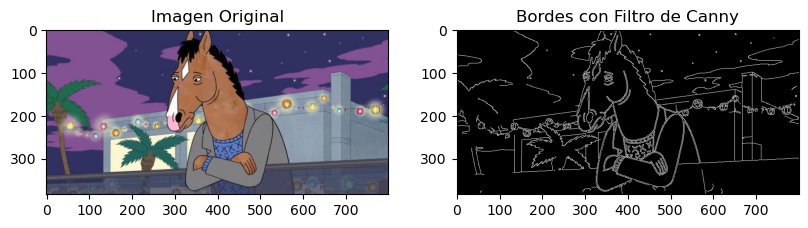

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_canny(img,umbral_bajo=100,umbral_alto=200):# mas optimizado para que no tenga mucho ruido
    img_gris=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bordes=cv2.Canny(img_gris,umbral_bajo,umbral_alto)
    return bordes

img=cv2.imread('imagen1.jpg')
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.title('Bordes con Filtro de Canny')
bordes=filtro_canny(img)
plt.imshow(bordes, cmap='gray')
plt.show()